Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import transformers
transformers.logging.set_verbosity_error()

In [ ]:
!pip install -U bitsandbytes transformers accelerate peft trl

Load raw JSON dataset from Drive

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/content/drive/MyDrive/Algebra_Model/Data/algebra_formatted.jsonl",
    split="train"
)

dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

Load the Base Model

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model.eval()
print("BASE model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

BASE model loaded!


Ask Function

In [ ]:
FORMAT_RULES = """
Formatting rules only:
- Do not use unicode exponents like ² or ³.
- Do not use ^ for powers. Use ** instead.
- Use explicit multiplication, e.g. 7*c instead of 7c.
- Do not write any explanations or sentences.
- Do not write phrases like "Let's", "Now", "Given", "LHS", or "RHS".
- Write only numbered algebra steps.
- End with exactly one final line beginning with:
Final:
- The final line must contain the full equation.
- Format the last line as:
Final: <left-hand side> = <right-hand side>.
"""

def ask(prompt):
    full_prompt = f"""{prompt}

{FORMAT_RULES}
"""

    inputs = tokenizer(full_prompt, return_tensors="pt").to(model.device)

    output = model.generate(
        **inputs,
        max_new_tokens=400,
        do_sample=False,
        temperature=0.2,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
    )

    generated = output[0][inputs.input_ids.shape[-1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

Base Model Evaluation

---



In [ ]:
import re
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from sympy import simplify, parse_expr

# ===== CHANGE THIS EACH TIME YOU SWITCH MODELS =====
MODEL_LABEL = "BASE"

# ===== Helper functions =====
FINAL_PAT = re.compile(r"Final:\s*(.+?)(?:\.|\n|$)", re.IGNORECASE)

def extract_final_equation(text: str):
    m = FINAL_PAT.findall(text)
    if not m:
        return None
    return m[-1].strip()

def parse_equation(eq_text: str):
    if eq_text is None or "=" not in eq_text:
        return None, None
    left, right = eq_text.split("=", 1)
    try:
        left_expr = parse_expr(left.strip(), evaluate=True)
        right_expr = parse_expr(right.strip(), evaluate=True)
        return left_expr, right_expr
    except Exception:
        return None, None

def theorem_from_prompt(prompt: str):
    lines = prompt.split("\n")
    if len(lines) >= 2:
        return lines[1].strip()
    return ""

def clean_output(raw: str):
    clean = raw.split("Show each algebra step clearly.")[-1]
    if "Final:" in clean:
        clean = clean.split("Final:")[0] + "Final:" + clean.split("Final:")[1].split("\n")[0]
    return clean.strip()

def check_correctness(model_output: str, truth_completion: str):
    pred = extract_final_equation(model_output)
    truth = extract_final_equation(truth_completion)

    if pred is None or truth is None:
        return 0

    if pred.replace(" ", "") == truth.replace(" ", ""):
        return 1

    pred_l, pred_r = parse_equation(pred)
    truth_l, truth_r = parse_equation(truth)

    if None in (pred_l, pred_r, truth_l, truth_r):
        return 0

    try:
        pred_ok = simplify(pred_l - pred_r) == 0
        truth_ok = simplify(truth_l - truth_r) == 0
        lhs_match = simplify(pred_l - truth_l) == 0
        rhs_match = simplify(pred_r - truth_r) == 0

        if pred_ok and truth_ok and lhs_match and rhs_match:
            return 1
    except Exception:
        pass

    return 0

def formatting_score(model_output: str):
    has_final = 1 if "Final:" in model_output else 0
    has_step = 1 if re.search(r"(?:\bStep\s*)?\d+\s*:", model_output) else 0
    return 1 if (has_final and has_step) else 0

def step_count(model_output: str):
    return len(re.findall(r"(?:\bStep\s*)?\d+\s*:", model_output))

def token_count(model_output: str):
    return len(tokenizer(model_output)["input_ids"])

# ===== Evaluate on all test identities =====
results = []

for idx, ex in enumerate(test_dataset):
    prompt = ex["prompt"]
    truth_completion = ex["completion"]

    raw = ask(prompt)
    clean = clean_output(raw)

    results.append({
        "model": MODEL_LABEL,
        "idx": idx,
        "theorem": theorem_from_prompt(prompt),
        "ground_truth": truth_completion,
        "model_output": clean,
        "correct": check_correctness(clean, truth_completion),
        "formatted": formatting_score(clean),
        "steps": step_count(clean),
        "tokens": token_count(clean),
        "has_final": 1 if extract_final_equation(clean) is not None else 0
    })

    if idx % 25 == 0:
        print(f"Finished {idx}/{len(test_dataset)}")

df = pd.DataFrame(results)

# ===== Save raw outputs =====
save_dir = "/content/drive/MyDrive/Algebra_Model/BASE_Results"
os.makedirs(save_dir, exist_ok=True)

csv_path = f"{save_dir}/{MODEL_LABEL.lower()}_test_results.csv"
df.to_csv(csv_path, index=False)
print(f"Saved raw results to: {csv_path}")

# ===== Summary metrics =====
summary = {
    "model": MODEL_LABEL,
    "n_test": len(df),
    "accuracy": df["correct"].mean(),
    "formatting_rate": df["formatted"].mean(),
    "final_rate": df["has_final"].mean(),
    "avg_steps": df["steps"].mean(),
    "avg_tokens": df["tokens"].mean(),
}

summary_df = pd.DataFrame([summary])
summary_path = f"{save_dir}/{MODEL_LABEL.lower()}_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nSUMMARY")
print(summary_df)

# ===== Plots for this one model =====

# 1. Correct vs Incorrect
plt.figure(figsize=(5,4))
counts = df["correct"].value_counts().sort_index()
plt.bar(["Incorrect", "Correct"], [counts.get(0, 0), counts.get(1, 0)])
plt.ylabel("Count")
plt.title(f"{MODEL_LABEL}: Correct vs Incorrect")
plt.tight_layout()
plt.savefig(f"{save_dir}/{MODEL_LABEL.lower()}_correctness_bar.png")
plt.show()

# 2. Formatting compliance
plt.figure(figsize=(5,4))
fmt_counts = df["formatted"].value_counts().sort_index()
plt.bar(["Bad format", "Good format"], [fmt_counts.get(0, 0), fmt_counts.get(1, 0)])
plt.ylabel("Count")
plt.title(f"{MODEL_LABEL}: Formatting Compliance")
plt.tight_layout()
plt.savefig(f"{save_dir}/{MODEL_LABEL.lower()}_formatting_bar.png")
plt.show()

# 3. Step count distribution
plt.figure(figsize=(6,4))
plt.hist(df["steps"], bins=range(0, max(df["steps"]) + 2), align="left", rwidth=0.8)
plt.xlabel("Number of steps")
plt.ylabel("Count")
plt.title(f"{MODEL_LABEL}: Step Count Distribution")
plt.tight_layout()
plt.savefig(f"{save_dir}/{MODEL_LABEL.lower()}_steps_hist.png")
plt.show()

NameError: name 'test_dataset' is not defined

Generating train split: 0 examples [00:00, ? examples/s]

Loaded OOD dataset: 300
Finished 0/300
Finished 25/300
Finished 50/300
Finished 75/300
Finished 100/300
Finished 125/300
Finished 150/300
Finished 175/300
Finished 200/300
Finished 225/300
Finished 250/300
Finished 275/300

OOD SUMMARY
      model  n_test  accuracy  formatting_rate  final_rate  avg_steps  \
0  BASE_OOD     300  0.476667         0.656667    0.656667  11.126667   

   avg_tokens  
0      285.12  


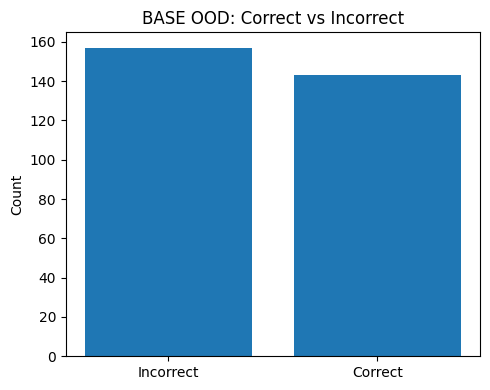

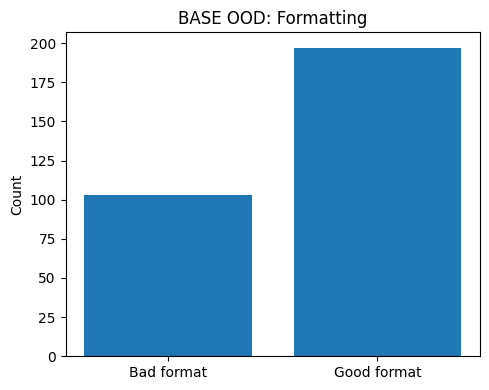

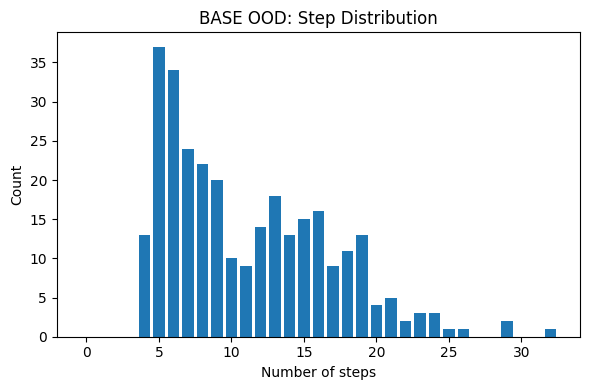

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import os

# ===== OOD dataset path =====
ood_path = "/content/drive/MyDrive/Algebra_Model/Data/ood_algebra_testset_300.jsonl"

# ===== Load dataset =====
ood_dataset = load_dataset("json", data_files=ood_path, split="train")

print("Loaded OOD dataset:", len(ood_dataset))

# ===== Label =====
MODEL_LABEL = "BASE_OOD"

# ===== Evaluation =====
results = []

for idx, ex in enumerate(ood_dataset):
    theorem = ex["theorem"]
    truth_completion = ex["proof"]
    prompt = f"Prove the following algebraic identity:\n{theorem}"

    raw = ask(prompt)
    clean = clean_output(raw)

    results.append({
        "model": MODEL_LABEL,
        "idx": idx,
        "theorem": theorem,
        "ground_truth": truth_completion,
        "model_output": clean,
        "correct": check_correctness(clean, truth_completion),
        "formatted": formatting_score(clean),
        "steps": step_count(clean),
        "tokens": token_count(clean),
        "has_final": 1 if extract_final_equation(clean) is not None else 0
    })

    if idx % 25 == 0:
        print(f"Finished {idx}/{len(ood_dataset)}")

df = pd.DataFrame(results)

# ===== Save results =====
save_dir = "/content/drive/MyDrive/Algebra_Model/BASE_OOD"
os.makedirs(save_dir, exist_ok=True)

df.to_csv(f"{save_dir}/base_ood_test_results.csv", index=False)

summary = {
    "model": MODEL_LABEL,
    "n_test": len(df),
    "accuracy": df["correct"].mean(),
    "formatting_rate": df["formatted"].mean(),
    "final_rate": df["has_final"].mean(),
    "avg_steps": df["steps"].mean(),
    "avg_tokens": df["tokens"].mean(),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"{save_dir}/base_ood_summary.csv", index=False)

print("\nOOD SUMMARY")
print(summary_df)

# ===== Plots =====

# Correct vs Incorrect
plt.figure(figsize=(5, 4))
counts = df["correct"].value_counts().sort_index()
plt.bar(["Incorrect", "Correct"], [counts.get(0, 0), counts.get(1, 0)])
plt.ylabel("Count")
plt.title("BASE OOD: Correct vs Incorrect")
plt.tight_layout()
plt.savefig(f"{save_dir}/base_ood_correctness_bar.png")
plt.show()

# Formatting
plt.figure(figsize=(5, 4))
fmt_counts = df["formatted"].value_counts().sort_index()
plt.bar(["Bad format", "Good format"], [fmt_counts.get(0, 0), fmt_counts.get(1, 0)])
plt.ylabel("Count")
plt.title("BASE OOD: Formatting")
plt.tight_layout()
plt.savefig(f"{save_dir}/base_ood_formatting_bar.png")
plt.show()

# Steps
plt.figure(figsize=(6, 4))
plt.hist(df["steps"], bins=range(0, max(df["steps"]) + 2), align="left", rwidth=0.8)
plt.xlabel("Number of steps")
plt.ylabel("Count")
plt.title("BASE OOD: Step Distribution")
plt.tight_layout()
plt.savefig(f"{save_dir}/base_ood_steps_hist.png")
plt.show()